### Loading env

In [45]:
import os

In [ ]:
from dotenv import load_dotenv

load_dotenv()  # laods the env file

True

In [47]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

### Loading model

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.0, max_retries=2)
llm.invoke("Hello bud welcome to my chat app")

AIMessage(content="Nice to meet you. What's on your mind? Want to chat about something in particular or just shoot the breeze?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 42, 'total_tokens': 67, 'completion_time': 0.033333333, 'prompt_time': 0.002490482, 'queue_time': 0.048565408, 'total_time': 0.035823815}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f7bd09b454', 'finish_reason': 'stop', 'logprobs': None}, id='run--27cb8ef7-e219-4bcd-89a4-f0cea7ed0592-0', usage_metadata={'input_tokens': 42, 'output_tokens': 25, 'total_tokens': 67})

### Creating the structure of graph

In [ ]:
from typing import (
    Annotated,
)  # helps to document and specify the type or purpose of data

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
graph_builder = StateGraph(State)  # building a graph

### Creating a new node

In [ ]:
def chatbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }  # returns a dict with key as messages, it will be appended to the list of messages present in state


graph_builder.add_node(chatbot)  # adding the method to  node

In [ ]:
graph_builder.add_edge(START, "chatbot")

In [53]:
graph = graph_builder.compile()

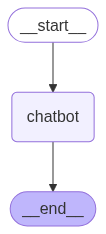

In [56]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### Streaming the ouput

In [ ]:
def stream_graph_updates(user_input: str):
  for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
    for value in event.values():
      last_msg = value["messages"][-1]
      if isinstance(last_msg, AIMessage):
          print("Assistant:", last_msg.content)


while True:
  try:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    stream_graph_updates(user_input)
  except:
    user_input = "What do you know about LangGraph?"
    print("User: " + user_input)
    stream_graph_updates(user_input)
    break

Assistant: Langraph is a powerful tool for building chatbots. Here are some tips and ideas to help you take your chatbot building skills to the next level:

1. **Improve your understanding of natural language processing (NLP)**: Langraph uses NLP to understand user input and generate responses. Study NLP concepts, such as tokenization, stemming, and lemmatization, to improve your chatbot's accuracy.
2. **Use intent-based design**: Instead of relying on keyword matching, design your chatbot to understand user intent. This will help you create more accurate and relevant responses.
3. **Create a knowledge graph**: A knowledge graph is a database that stores information about entities, relationships, and concepts. Use Langraph to create a knowledge graph that your chatbot can draw upon to answer user questions.
4. **Use entity recognition**: Entity recognition is the process of identifying and extracting specific entities from user input, such as names, locations, and dates. Use Langraph t